In [2]:
# requires gseapy:
# pip install gseapy

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gseapy as gp

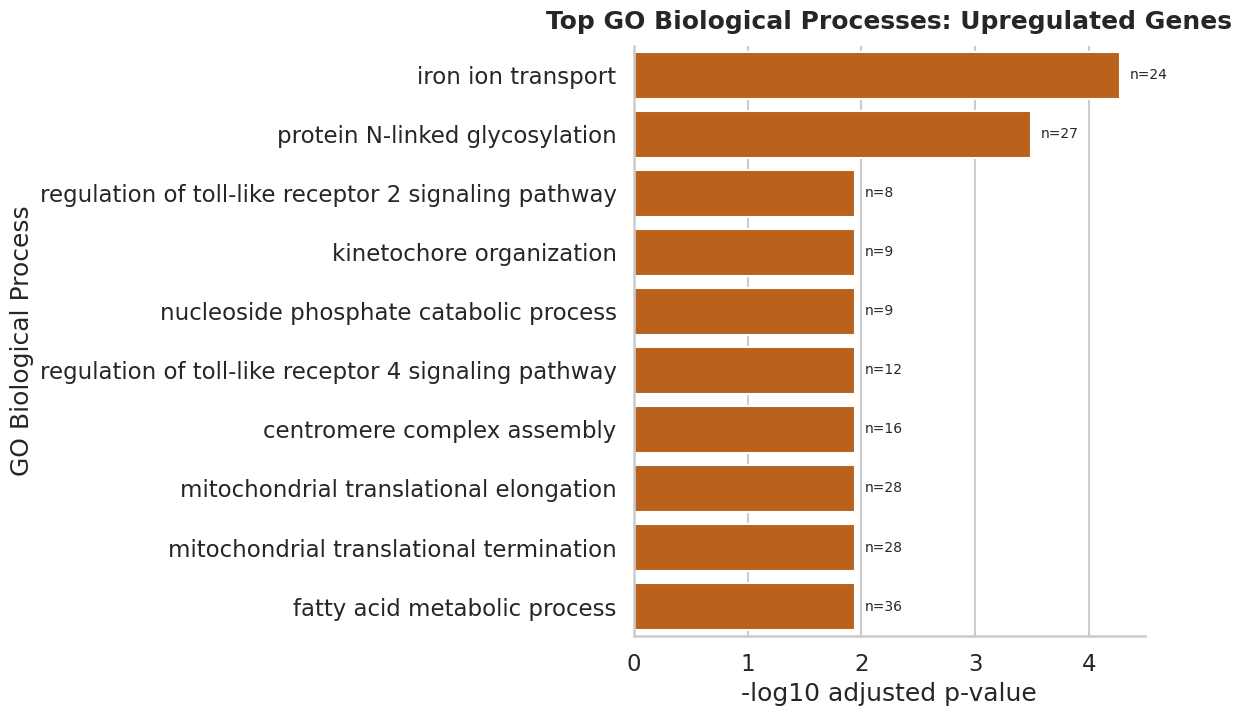

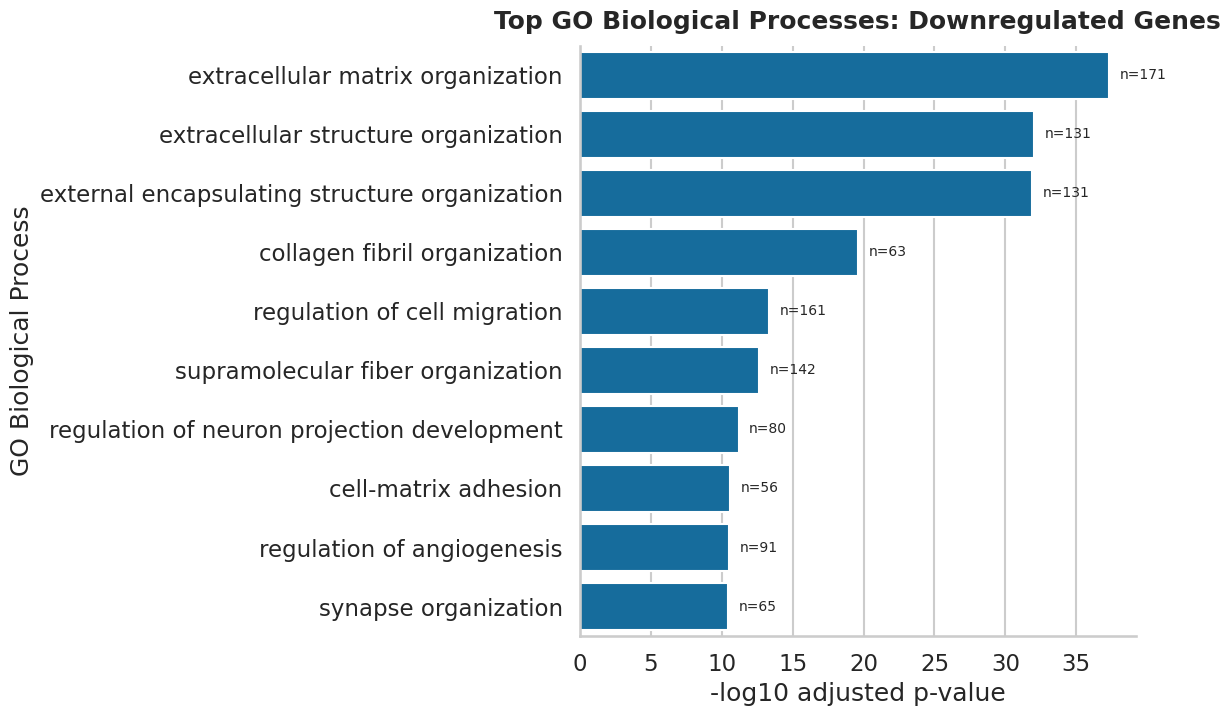

In [8]:
# GO and KEGG pathway enrichment analysis using gseapy
project_dir = Path.cwd().parent
deg_matrix = pd.read_csv(project_dir / "quants" / "GSE60450_deseq2_results.csv", index_col=0)

# Filter gene list for GO/KEGG analysisbased on adjusted p-value and log2 fold change
deg_significant_matrix_up = deg_matrix[(deg_matrix["padj"] < 0.05) & (deg_matrix["log2FoldChange"] > 1)].copy()
gene_list_up = deg_significant_matrix_up["gene_name"].dropna().astype(str).drop_duplicates().tolist()
deg_significant_matrix_down = deg_matrix[(deg_matrix["padj"] < 0.05) & (deg_matrix["log2FoldChange"] < -1)].copy()
gene_list_down = deg_significant_matrix_down["gene_name"].dropna().astype(str).drop_duplicates().tolist()


# Perform GO enrichment analysis for upregulated genes
go_enrichment_up = gp.enrichr(
    gene_list=gene_list_up,
    gene_sets="GO_Biological_Process_2021",   # for human use "GO_Biological_Process_2021"
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_GO"),
    cutoff=0.05
)
go_up_df = go_enrichment_up.results.copy()
go_up_df.to_csv(project_dir / "quants" / "GSE60450_GO" / "GSE60450_GO_enrichment_up_results.csv", index=False)

# Perform GO enrichment analysis for downregulated genes
go_enrichment_down = gp.enrichr(
    gene_list=gene_list_down,
    gene_sets="GO_Biological_Process_2021",   # for human use "GO_Biological_Process_2021"
    organism="mouse",
    outdir=str(project_dir / "quants" / "GSE60450_GO"),
    cutoff=0.05
)
go_down_df = go_enrichment_down.results.copy()
go_down_df.to_csv(project_dir / "quants" / "GSE60450_GO" / "GSE60450_GO_enrichment_down_results.csv", index=False)

# Plot GO enrichment results with matplotlib / seaborn
sns.set_theme(style="whitegrid", context="talk")
go_output_dir = project_dir / "quants" / "GSE60450_GO"
go_output_dir.mkdir(parents=True, exist_ok=True)

def prepare_go_plot_df(results_df, top_n=10):
    if results_df.empty:
        return pd.DataFrame()

    plot_df = results_df.copy()
    plot_df["Adjusted P-value"] = pd.to_numeric(plot_df["Adjusted P-value"], errors="coerce")
    plot_df["Combined Score"] = pd.to_numeric(plot_df.get("Combined Score"), errors="coerce")

    if "Overlap" in plot_df.columns:
        plot_df["Gene Count"] = plot_df["Overlap"].str.split("/").str[0].astype(float)
    else:
        plot_df["Gene Count"] = np.nan

    plot_df = plot_df.dropna(subset=["Term", "Adjusted P-value"])
    plot_df = plot_df[plot_df["Adjusted P-value"] > 0].copy()
    plot_df = plot_df.sort_values(["Adjusted P-value", "Combined Score"], ascending=[True, False]).head(top_n).copy()
    plot_df["-log10(adj p-value)"] = -np.log10(plot_df["Adjusted P-value"])
    plot_df["Term"] = plot_df["Term"].str.replace(r" \(GO:\d+\)$", "", regex=True)

    return plot_df.sort_values("-log10(adj p-value)", ascending=False)

def plot_go_barplot(results_df, title, color, output_path, top_n=10):
    plot_df = prepare_go_plot_df(results_df, top_n=top_n)

    if plot_df.empty:
        print(f"No GO terms passed filtering for {title}.")
        return

    fig_height = max(4, 0.6 * len(plot_df) + 1.5)
    fig, ax = plt.subplots(figsize=(12, fig_height))
    sns.barplot(data=plot_df, x="-log10(adj p-value)", y="Term", color=color, ax=ax)

    ax.set_title(title, pad=12, weight="bold")
    ax.set_xlabel("-log10 adjusted p-value")
    ax.set_ylabel("GO Biological Process")
    ax.spines[["top", "right"]].set_visible(False)

    if plot_df["Gene Count"].notna().any():
        x_offset = plot_df["-log10(adj p-value)"].max() * 0.02
        for patch, gene_count in zip(ax.patches, plot_df["Gene Count"]):
            if pd.notna(gene_count):
                ax.text(
                    patch.get_width() + x_offset,
                    patch.get_y() + patch.get_height() / 2,
                    f"n={int(gene_count)}",
                    va="center",
                    fontsize=10,
                )

    plt.tight_layout()
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

plot_go_barplot(
    go_up_df,
    title="Top GO Biological Processes: Upregulated Genes",
    color="#D55E00",
    output_path=go_output_dir / "GSE60450_GO_up_barplot.png",
)

plot_go_barplot(
    go_down_df,
    title="Top GO Biological Processes: Downregulated Genes",
    color="#0072B2",
    output_path=go_output_dir / "GSE60450_GO_down_barplot.png",
)
